Train shape: (820, 13)
Test shape: (205, 13)

Best Parameters:
{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 1}

Model Performance:
Accuracy : 0.9854
Precision: 1.0000
Recall   : 0.9714
F1 Score : 0.9855

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



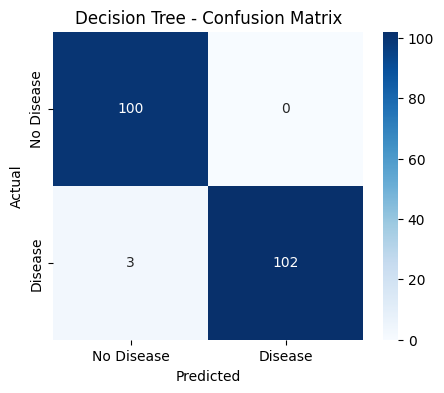


Model saved successfully!


In [7]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv(r"cleaned_data.csv")

X = df.drop(columns=['target'])
y = df['target']


X_encoded = pd.get_dummies(X)

joblib.dump(list(X_encoded.columns), "model_features.joblib")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, 9],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)


print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nModel Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

joblib.dump(best_model, "heart_disease_decision_tree_model.joblib")

print("\nModel saved successfully!")

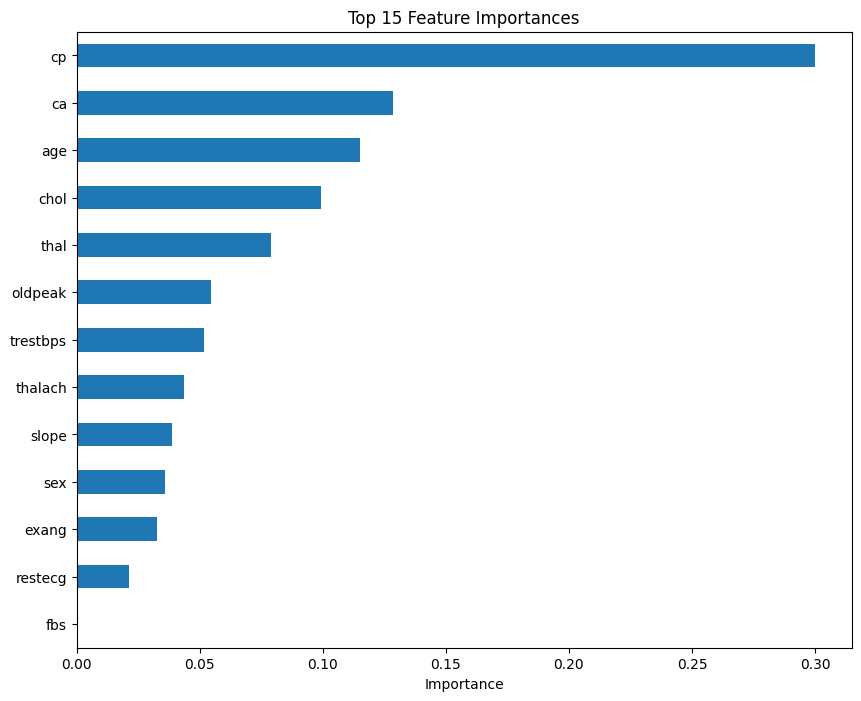

          importance
cp          0.299922
ca          0.128631
age         0.114920
chol        0.099451
thal        0.079146
oldpeak     0.054481
trestbps    0.051820
thalach     0.043466
slope       0.038558
sex         0.035869
exang       0.032445
restecg     0.021291
fbs         0.000000


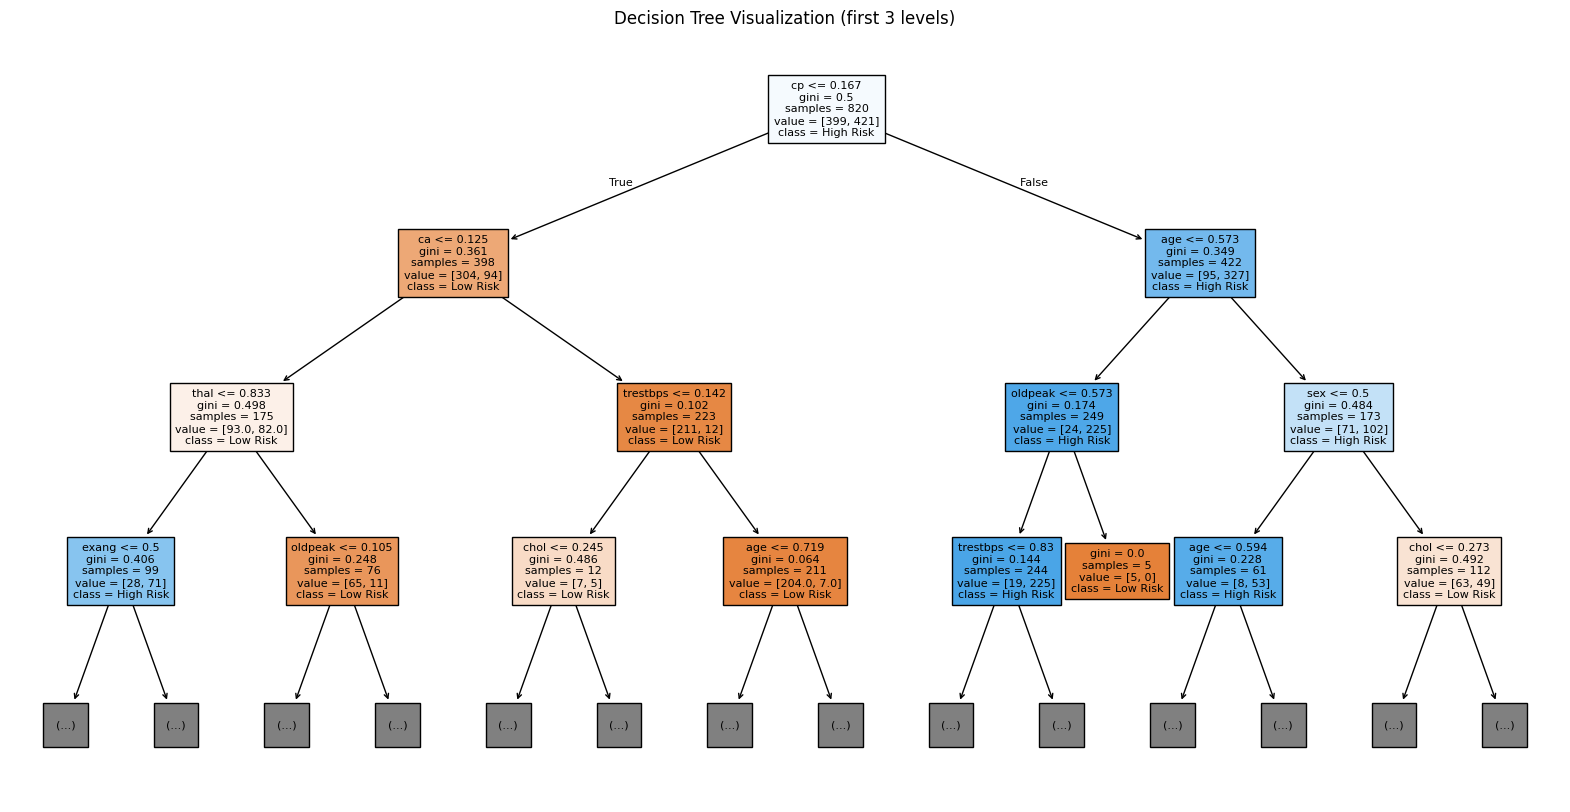

In [8]:
from sklearn.tree import plot_tree

importance = pd.Series(
    best_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

print(importance.head(15).to_frame("importance"))

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X_encoded.columns,
    class_names=["Low Risk", "High Risk"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (first 3 levels)")
plt.show()